In [93]:
# ============================================================
# Cell 1 -- Imports
# ============================================================

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.visualization import plot_histogram

In [ ]:
# ============================================================
# Cell 2 -- Problem setup
# ============================================================
# The paper prescribes sorting items by decreasing profit-to-weight
# density before running the QTG. 
#
# Original items:  weights = [2, 1, 1],  profits = [3, 2, 2]
# Densities:       [1.5, 2.0, 2.0]
# After sorting by decreasing density:

weights = [1, 1, 2]
profits = [2, 2, 3]
capacity = 3
n_items = len(weights)

# --- Register sizes ---
# Capacity register: must hold values 0..c.  We need the MSB to act
# as a sign indicator for our comparison circuit.  With 3 qubits we
# can represent 0-7; values 0-3 (MSB=0) are non-negative and
# values 4-7 (MSB=1) signal underflow.  This works because c=3 < 4=2^2.
n_cap = 3

# Profit register: max possible profit = 2+2+3 = 7, fits in 3 qubits.
n_prof = 3

# --- Greedy solution (classical preprocessing) ---
# Pack items greedily in sorted order:
#   item 0 (w=1): take it, remaining = 2
#   item 1 (w=1): take it, remaining = 1
#   item 2 (w=2): skip   (2 > 1)
# Greedy solution x' = [1, 1, 0], profit = 4
greedy_solution = [1, 1, 0]
greedy_profit = 4

# Threshold for the oracle: we want solutions strictly better than
# the greedy, so threshold = greedy_profit + 1 = 5.
threshold = greedy_profit + 1

# --- Bias parameter (Eq. 5 of the paper) ---
# The paper uses Delta=4 and b = n/4 for their experiments.
b = n_items / 4   # 0.75

print(f'Items (sorted by density):  weights={weights}, profits={profits}')
print(f'Capacity: {capacity}')
print(f'Greedy solution: {greedy_solution}  (profit={greedy_profit})')
print(f'Threshold for oracle: profit >= {threshold}')
print(f'Bias parameter b = {b}')

Items (sorted by density):  weights=[1, 1, 2], profits=[2, 2, 3]
Capacity: 3
Greedy solution: [1, 1, 0]  (profit=4)
Threshold for oracle: profit >= 5
Bias parameter b = 0.75


In [95]:
# ============================================================
# Cell 3 -- Biased Ry angles (Eq. 3 of the paper)
# ============================================================
#
# The QTG does NOT use a balanced Hadamard.  Instead it applies a
# biased Ry rotation whose angle depends on:
#   - the bias parameter b
#   - the bit x'_m of the greedy (intermediate) solution
#
# If x'_m = 0 (greedy did NOT take this item):
#   theta_0 = 2 * arccos( sqrt( (1+b)/(2+b) ) )
#   P(include) = 1/(2+b),  P(exclude) = (1+b)/(2+b)
#   -> the rotation favours exclusion, mirroring the greedy.
#
# If x'_m = 1 (greedy DID take this item):
#   theta_1 = 2 * arccos( sqrt( 1/(2+b) ) )
#   P(include) = (1+b)/(2+b),  P(exclude) = 1/(2+b)
#   -> the rotation favours inclusion, mirroring the greedy.

def ry_angle(greedy_bit, b):
    if greedy_bit == 0:
        return 2 * np.arccos(np.sqrt((1 + b) / (2 + b)))
    else:
        return 2 * np.arccos(np.sqrt(1 / (2 + b)))

angles = [ry_angle(greedy_solution[m], b) for m in range(n_items)]

for m in range(n_items):
    p_include = np.sin(angles[m] / 2) ** 2
    print(f'Item {m}: greedy_bit={greedy_solution[m]}, '
          f'theta={angles[m]:.4f} rad, '
          f'P(include)={p_include:.4f}, P(exclude)={1 - p_include:.4f}')

Item 0: greedy_bit=1, theta=1.8470 rad, P(include)=0.6364, P(exclude)=0.3636
Item 1: greedy_bit=1, theta=1.8470 rad, P(include)=0.6364, P(exclude)=0.3636
Item 2: greedy_bit=0, theta=1.2946 rad, P(include)=0.3636, P(exclude)=0.6364


In [ ]:
# ============================================================
# Cell 4 -- QFT gate helpers and QFT-based arithmetic
# ============================================================


_qft_cache = {}
_iqft_cache = {}

def qft_gate(n):
    """Return a QFT *gate* (not circuit) for n qubits, cached."""
    if n not in _qft_cache:
        _qft_cache[n] = synth_qft_full(n, do_swaps=False).to_gate()
    return _qft_cache[n]

def iqft_gate(n):
    """Return an inverse-QFT *gate* for n qubits, cached."""
    if n not in _iqft_cache:
        _iqft_cache[n] = qft_gate(n).inverse()
    return _iqft_cache[n]


# --- Draper adders ---

def add_const_fourier(qc, reg, a):
    """Add classical integer 'a' to register already in Fourier basis."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.p(angle, reg[j])

def ctrl_add_const_fourier(qc, ctrl, reg, a):
    """Controlled add: add 'a' if control qubit is |1>."""
    n = len(reg)
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.cp(angle, ctrl, reg[j])

print('QFT gate helpers and arithmetic functions defined.')

QFT gate helpers and arithmetic functions defined.


In [97]:
# ============================================================
# Cell 5 -- Quantum comparator: "is capacity >= w?"
# ============================================================
#
# This is the gate C^2_{>= w_m} from Eq. 4 of the paper.
#
# Technique:
#   1.  Subtract w_m from cap register (QFT arithmetic).
#   2.  MSB = 0 => non-negative => cap >= w_m
#       MSB = 1 => underflow    => cap <  w_m
#   3.  Copy comparison result into ancilla via CNOT.
#   4.  Add w_m back to restore cap register.

def compare_geq(qc, cap_reg, ancilla, value, n_cap):
    msb = n_cap - 1

    # subtract value
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, -value)
    qc.append(iqft_gate(n_cap), cap_reg)

    # read sign bit: MSB=0 means cap>=w, flip to get ancilla=1
    qc.x(cap_reg[msb])
    qc.cx(cap_reg[msb], ancilla)
    qc.x(cap_reg[msb])

    # restore cap register
    qc.append(qft_gate(n_cap), cap_reg)
    add_const_fourier(qc, cap_reg, value)
    qc.append(iqft_gate(n_cap), cap_reg)

# Same circuit uncomputes the ancilla (self-inverse).
uncompare_geq = compare_geq



print('Quantum comparator defined.')

Quantum comparator defined.


In [98]:
# ============================================================
# Cell 6 -- Build the QTG circuit
# ============================================================
#
# G = U_1 . U_2 . ... . U_n
# Each U_m:
#   U^1_m : controlled on (cap >= w_m), apply biased Ry to path[m]
#   U^2_m : controlled on path[m]=1, subtract w_m from cap
#   U^3_m : controlled on path[m]=1, add p_m to profit

def build_qtg(n_items, weights, profits, capacity, n_cap, n_prof,
              greedy_solution, b):
    total_qubits = n_items + n_cap + n_prof + 1
    qc = QuantumCircuit(total_qubits, name='QTG')

    path_q = list(range(0, n_items))
    cap_q  = list(range(n_items, n_items + n_cap))
    prof_q = list(range(n_items + n_cap, n_items + n_cap + n_prof))
    anc_q  = n_items + n_cap + n_prof

    # Initialize capacity register to c (binary, LSB first)
    for bit_idx in range(n_cap):
        if (capacity >> bit_idx) & 1:
            qc.x(cap_q[bit_idx])

    # Process each item
    for m in range(n_items):
        theta = ry_angle(greedy_solution[m], b)

        # U^1_m -- biased superposition, controlled on cap >= w_m
        compare_geq(qc, cap_q, anc_q, weights[m], n_cap)
        qc.cry(theta, anc_q, path_q[m])
        uncompare_geq(qc, cap_q, anc_q, weights[m], n_cap)

        # U^2_m -- subtract w_m from cap, controlled on path[m]
        qc.append(qft_gate(n_cap), cap_q)
        ctrl_add_const_fourier(qc, path_q[m], cap_q, -weights[m])
        qc.append(iqft_gate(n_cap), cap_q)

        # U^3_m -- add p_m to profit, controlled on path[m]
        qc.append(qft_gate(n_prof), prof_q)
        ctrl_add_const_fourier(qc, path_q[m], prof_q, profits[m])
        qc.append(iqft_gate(n_prof), prof_q)

        #qc.barrier()

    return qc

qtg_circ = build_qtg(n_items, weights, profits, capacity,
                      n_cap, n_prof, greedy_solution, b)
print(f'QTG uses {qtg_circ.num_qubits} qubits')
print(f'  path: {n_items}, capacity: {n_cap}, profit: {n_prof}, ancilla: 1')

QTG uses 10 qubits
  path: 3, capacity: 3, profit: 3, ancilla: 1


## Part A -- Verify the QTG superposition (no amplification)

Before adding the Grover iteration, we run the bare QTG and
measure the **path register** to confirm that:

1. Only **feasible** states (total weight $\leq$ capacity) appear.  
2. The probability distribution is **non-uniform** and biased toward
   solutions close to the greedy solution $x' = 110$.

In [99]:
# ============================================================
# Cell 7 -- Run QTG alone and inspect the output
# ============================================================

path_reg = QuantumRegister(n_items, 'path')
cap_reg  = QuantumRegister(n_cap, 'cap')
prof_reg = QuantumRegister(n_prof, 'prof')
anc_reg  = QuantumRegister(1, 'anc')
c_path   = ClassicalRegister(n_items, 'c_path')
c_prof   = ClassicalRegister(n_prof, 'c_prof')

qc_test = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                         c_path, c_prof)

# Append QTG as a gate 
all_qubits = list(range(qc_test.num_qubits))
qc_test.append(qtg_circ.to_gate(), all_qubits)
qc_test.barrier()

# Measure path and profit registers
qc_test.measure(path_reg, c_path)
qc_test.measure(prof_reg, c_prof)

# Simulate
sampler = AerSampler()
job = sampler.run([qc_test], shots=20000)
result = job.result()
counts = result.quasi_dists[0].binary_probabilities()

print('Raw measurement outcomes (c_prof  c_path) :')
for bitstr, prob in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {bitstr}  ->  prob = {prob:.4f}')

Raw measurement outcomes (c_prof  c_path) :
  100011  ->  prob = 0.4047
  010010  ->  prob = 0.1492
  010001  ->  prob = 0.1489
  000000  ->  prob = 0.0847
  101110  ->  prob = 0.0843
  101101  ->  prob = 0.0806
  011100  ->  prob = 0.0476


In [ ]:
# ============================================================
# Cell 8 -- display the QTG output
# ============================================================

path_probs = {}
decoded = []

for bitstr, prob in counts.items():
    prof_bits = bitstr[:n_prof]
    path_bits = bitstr[n_prof:]
    measured_profit = int(prof_bits, 2)
    path_probs[path_bits] = path_probs.get(path_bits, 0) + prob
    decoded.append((path_bits, measured_profit, prob))

print('Path register distribution (QTG alone, no amplification):')
print(f'{"Path":>6}  {"Weight":>6}  {"Profit":>6}  {"Feasible":>8}  {"Prob":>8}')
print('-' * 44)

for path_bits in sorted(path_probs.keys()):
    total_w = sum(weights[i] for i in range(n_items)
                  if path_bits[n_items - 1 - i] == '1')
    total_p = sum(profits[i] for i in range(n_items)
                  if path_bits[n_items - 1 - i] == '1')
    feasible = total_w <= capacity
    prob = path_probs[path_bits]
    marker = '  <-- OPTIMAL' if total_p == 5 and feasible else ''
    print(f'{path_bits:>6}  {total_w:>6}  {total_p:>6}  {str(feasible):>8}  '
          f'{prob:>8.4f}{marker}')

print('\nState 111 (weight=4) should have probability ~0 '
      'because the QTG never creates it.')

Path register distribution (QTG alone, no amplification):
  Path  Weight  Profit  Feasible      Prob
--------------------------------------------
   000       0       0      True    0.0847
   001       1       2      True    0.1489
   010       1       2      True    0.1492
   011       2       4      True    0.4047
   100       2       3      True    0.0476
   101       3       5      True    0.0806  <-- OPTIMAL
   110       3       5      True    0.0843  <-- OPTIMAL

State 111 (weight=4) should have probability ~0 because the QTG never creates it.


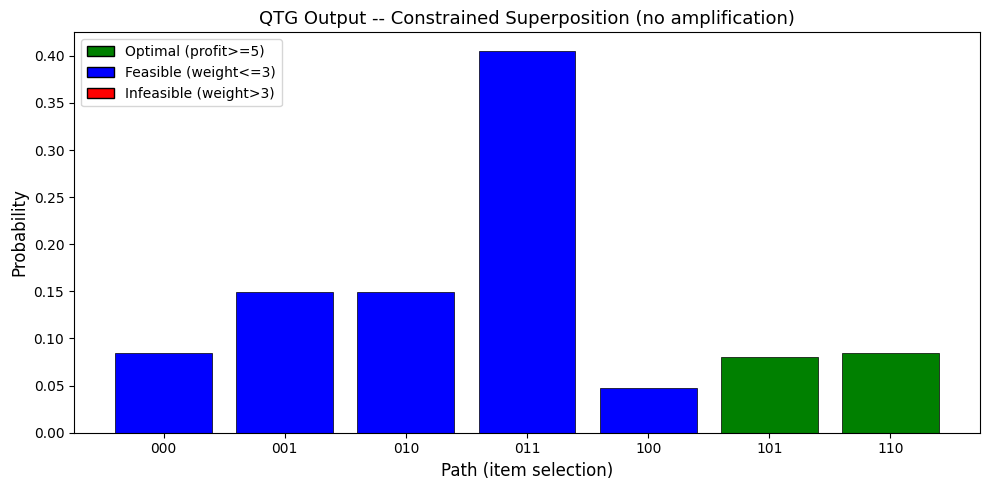

In [108]:
# ============================================================
# Cell 9 -- Histogram of QTG-only output
# ============================================================

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 5))

labels = sorted(path_probs.keys())
probs  = [path_probs[l] for l in labels]
colors = []
for l in labels:
    total_w = sum(weights[i] for i in range(n_items)
                  if l[n_items - 1 - i] == '1')
    total_p = sum(profits[i] for i in range(n_items)
                  if l[n_items - 1 - i] == '1')
    if total_p >= threshold and total_w <= capacity:
        colors.append('green')
    elif total_w <= capacity:
        colors.append('blue')
    else:
        colors.append('red')

ax.bar(labels, probs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Path (item selection)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('QTG Output -- Constrained Superposition (no amplification)',
             fontsize=13)

legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Optimal (profit>=5)'),
    Patch(facecolor='blue', edgecolor='black', label='Feasible (weight<=3)'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible (weight>3)'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

## Part B -- Amplitude amplification with a threshold oracle

Now we add one Grover iteration to boost the optimal solutions.

The Grover operator for amplitude amplification is:

$$G = \text{QTG} \;\cdot\; S_0 \;\cdot\; \text{QTG}^\dagger \;\cdot\; \text{Oracle}$$

where:
- **Oracle** flips the phase of states whose profit $\geq$ threshold,
  evaluated on the profit register via a quantum comparator.  
- $S_0 = 2|\psi_0\rangle\langle\psi_0| - I$ is the reflection about
  the initial state.

In [109]:
# ============================================================
# Cell 10 -- Threshold oracle
# ============================================================
#
# Examines the PROFIT register and flips the phase of states
# where profit >= threshold.
#

def threshold_oracle(qc, prof_q, anc_q, threshold, n_prof):
    msb = n_prof - 1

    # compute ancilla = (profit >= threshold)
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, -threshold)
    qc.append(iqft_gate(n_prof), prof_q)

    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # phase flip
    qc.z(anc_q)

    # uncompute ancilla
    qc.x(prof_q[msb])
    qc.cx(prof_q[msb], anc_q)
    qc.x(prof_q[msb])

    # restore profit register
    qc.append(qft_gate(n_prof), prof_q)
    add_const_fourier(qc, prof_q, threshold)
    qc.append(iqft_gate(n_prof), prof_q)

print(f'Threshold oracle defined (marks states with profit >= {threshold})')

Threshold oracle defined (marks states with profit >= 5)


In [110]:
# ============================================================
# Cell 11 -- Reflection about the initial state |psi_0>
# ============================================================
#
# |psi_0> = |000>_path  |cap_binary>_cap  |000>_prof  |0>_anc
#
# Steps:
#   1. Map |psi_0> -> |0...0> by flipping cap bits that are 1.
#   2. Reflect about |0...0>.
#   3. Undo step 1.

def reflect_initial_state(qc, all_qubits, cap_q, capacity, n_cap):
    # Step 1: map |psi_0> to |0...0>
    for bit_idx in range(n_cap):
        if (capacity >> bit_idx) & 1:
            qc.x(cap_q[bit_idx])

    # Step 2: reflect about |0...0>  (X-all, multi-CZ, X-all)
    for q in all_qubits:
        qc.x(q)

    target = all_qubits[-1]
    controls = all_qubits[:-1]
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)

    for q in all_qubits:
        qc.x(q)

    # Step 3: undo mapping
    for bit_idx in range(n_cap):
        if (capacity >> bit_idx) & 1:
            qc.x(cap_q[bit_idx])

print('Initial-state reflection operator defined.')

Initial-state reflection operator defined.


In [104]:
# ============================================================
# Cell 12 -- Full circuit: QTG + 1 Grover iteration
# ============================================================
#
#   1. QTG           -- prepare constrained superposition
#   2. Oracle         -- phase-flip states with profit >= threshold
#   3. QTG^dagger     -- undo state preparation
#   4. S_0            -- reflect about |psi_0>
#   5. QTG           -- redo state preparation
#   6. Measure

path_reg = QuantumRegister(n_items, 'path')
cap_reg  = QuantumRegister(n_cap, 'cap')
prof_reg = QuantumRegister(n_prof, 'prof')
anc_reg  = QuantumRegister(1, 'anc')
c_path   = ClassicalRegister(n_items, 'c_path')
c_prof   = ClassicalRegister(n_prof, 'c_prof')

qc_full = QuantumCircuit(path_reg, cap_reg, prof_reg, anc_reg,
                         c_path, c_prof)

all_q   = list(range(n_items + n_cap + n_prof + 1))
path_q  = list(range(0, n_items))
cap_q   = list(range(n_items, n_items + n_cap))
prof_q  = list(range(n_items + n_cap, n_items + n_cap + n_prof))
anc_idx = n_items + n_cap + n_prof

qtg_gate = qtg_circ.to_gate(label='QTG')
qtg_inv  = qtg_gate.inverse()
qtg_inv.label = 'QTG_dag'

# Step 1: QTG
qc_full.append(qtg_gate, all_q)
qc_full.barrier()

# Step 2: Threshold oracle
threshold_oracle(qc_full, prof_q, anc_idx, threshold, n_prof)
qc_full.barrier()

# Step 3: QTG inverse
qc_full.append(qtg_inv, all_q)
qc_full.barrier()

# Step 4: Reflection about |psi_0>
reflect_initial_state(qc_full, all_q, cap_q, capacity, n_cap)
qc_full.barrier()

# Step 5: QTG again
qc_full.append(qtg_gate, all_q)
qc_full.barrier()

# Step 6: Measure
qc_full.measure(path_reg, c_path)
qc_full.measure(prof_reg, c_prof)


print(f'Full circuit: {qc_full.num_qubits} qubits, '
      f'{qc_full.depth()} depth (before transpilation)')

Full circuit: 10 qubits, 21 depth (before transpilation)


In [105]:
# ============================================================
# Cell 13 -- Execute the full circuit
# ============================================================

sampler = AerSampler()
job_full = sampler.run([qc_full], shots=20000)
counts_full = job_full.result().quasi_dists[0].binary_probabilities()

path_probs_amp = {}
for bitstr, prob in counts_full.items():
    prof_bits = bitstr[:n_prof]
    path_bits = bitstr[n_prof:]
    path_probs_amp[path_bits] = path_probs_amp.get(path_bits, 0) + prob

print('Path register after 1 Grover iteration:')
print(f'{"Path":>6}  {"Weight":>6}  {"Profit":>6}  {"Feasible":>8}  {"Prob":>8}')
print('-' * 44)

for path_bits in sorted(path_probs_amp.keys()):
    total_w = sum(weights[i] for i in range(n_items)
                  if path_bits[n_items - 1 - i] == '1')
    total_p = sum(profits[i] for i in range(n_items)
                  if path_bits[n_items - 1 - i] == '1')
    feasible = total_w <= capacity
    prob = path_probs_amp[path_bits]
    marker = '  <-- OPTIMAL' if total_p == 5 and feasible else ''
    print(f'{path_bits:>6}  {total_w:>6}  {total_p:>6}  {str(feasible):>8}  '
          f'{prob:>8.4f}{marker}')

Path register after 1 Grover iteration:
  Path  Weight  Profit  Feasible      Prob
--------------------------------------------
   000       0       0      True    0.0847
   001       1       2      True    0.1466
   010       1       2      True    0.1501
   011       2       4      True    0.4070
   100       2       3      True    0.0478
   101       3       5      True    0.0799  <-- OPTIMAL
   110       3       5      True    0.0839  <-- OPTIMAL


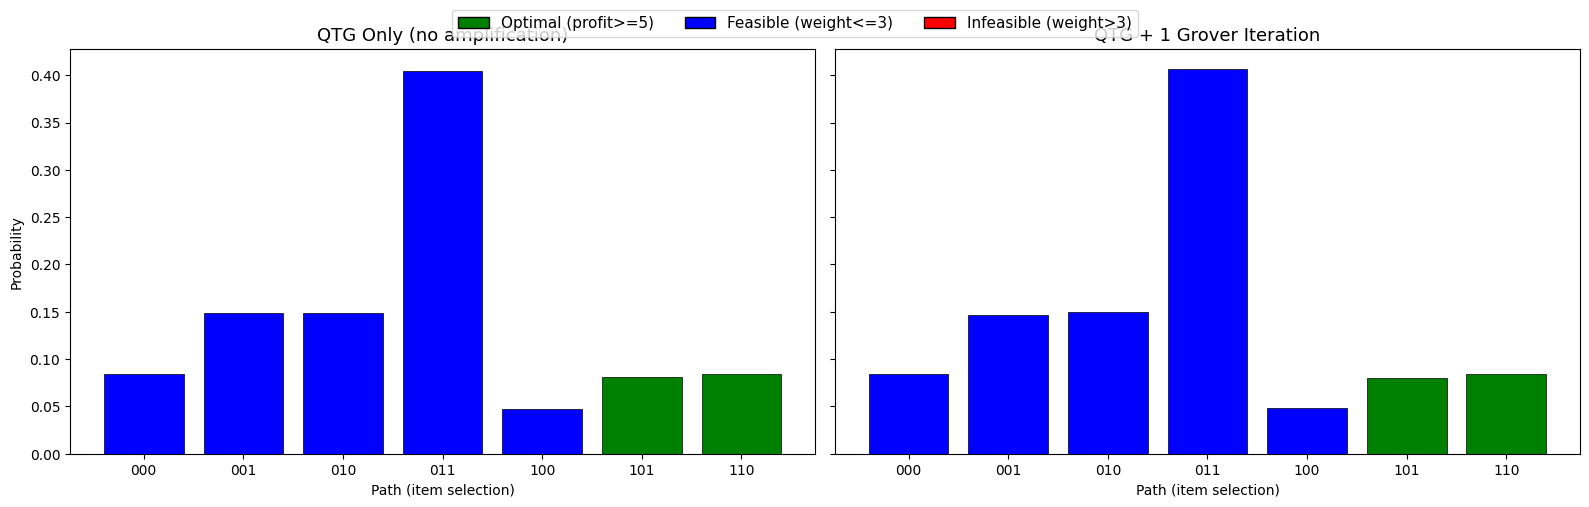

In [106]:
# ============================================================
# Cell 14 -- Side-by-side comparison: QTG alone vs. amplified
# ============================================================

from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

labels = sorted(set(list(path_probs.keys()) + list(path_probs_amp.keys())))

def get_color(l):
    total_w = sum(weights[i] for i in range(n_items)
                  if l[n_items - 1 - i] == '1')
    total_p = sum(profits[i] for i in range(n_items)
                  if l[n_items - 1 - i] == '1')
    if total_p >= threshold and total_w <= capacity:
        return 'green'
    elif total_w <= capacity:
        return 'blue'
    else:
        return 'red'

colors = [get_color(l) for l in labels]

probs1 = [path_probs.get(l, 0) for l in labels]
ax1.bar(labels, probs1, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('QTG Only (no amplification)', fontsize=13)
ax1.set_xlabel('Path (item selection)')
ax1.set_ylabel('Probability')

probs2 = [path_probs_amp.get(l, 0) for l in labels]
ax2.bar(labels, probs2, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('QTG + 1 Grover Iteration', fontsize=13)
ax2.set_xlabel('Path (item selection)')

legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Optimal (profit>=5)'),
    Patch(facecolor='blue', edgecolor='black', label='Feasible (weight<=3)'),
    Patch(facecolor='red', edgecolor='black', label='Infeasible (weight>3)'),
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=3, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [107]:
# ============================================================
# Cell 15 -- Classical verification of all solutions
# ============================================================

print('Complete enumeration of all 2^n = 8 assignments:')
print(f'{"Bitstring":>9}  {"Weight":>6}  {"Profit":>6}  {"Feasible":>8}  Note')
print('-' * 50)

for x in range(2 ** n_items):
    bits = format(x, f'0{n_items}b')
    total_w = sum(weights[i] for i in range(n_items)
                  if bits[n_items - 1 - i] == '1')
    total_p = sum(profits[i] for i in range(n_items)
                  if bits[n_items - 1 - i] == '1')
    feasible = total_w <= capacity
    note = ''
    if total_p == 5 and feasible:
        note = 'OPTIMAL'
    elif bits == '110':
        note = 'greedy'
    elif not feasible:
        note = 'infeasible'
    print(f'{bits:>9}  {total_w:>6}  {total_p:>6}  {str(feasible):>8}  {note}')

Complete enumeration of all 2^n = 8 assignments:
Bitstring  Weight  Profit  Feasible  Note
--------------------------------------------------
      000       0       0      True  
      001       1       2      True  
      010       1       2      True  
      011       2       4      True  
      100       2       3      True  
      101       3       5      True  OPTIMAL
      110       3       5      True  OPTIMAL
      111       4       7     False  infeasible


## Summary

This notebook implements the core of the Quantum Tree Generator (QTG) algorithm:

1. **Constrained superposition** -- The QTG builds feasibility into the state preparation itself. Each item is only offered to branches that can still accommodate its weight, so infeasible states are never created.

2. **Biased rotations** -- Instead of equal-probability Hadamards, the QTG uses parameterised $R_y$ gates that tilt the distribution toward the greedy solution, giving amplitude amplification a head start.

3. **Threshold oracle** -- Rather than hard-coding which states are good, we use a quantum comparator on the profit register. This scales to arbitrary instance sizes.

4. **Amplitude amplification** -- One Grover iteration (oracle, QTG$^\dagger$, initial-state reflection, QTG) significantly boosts the probability of measuring an optimal solution.

The side-by-side comparison shows how the amplification concentrates probability mass on the two optimal solutions (011 and 101, both with profit = 5).